# 12 - Cycle Hunt for the Claimed Long-Lived H1 Feature

We had not yet reproduced the long-lived cycle that motivated the
discussion. This notebook summarizes a deliberately broad search over
data, preprocessing, sampling, landmark counts, and filtration choices.

Updated short version:

- **Raw / sphere / whitened FLUX tokens:** no robust long-lived
  FLUX-specific `H1` cycle above controls in the earlier Rips-style
  sweeps.
- **Broader data:** CIFAR-10 and Fashion-MNIST did not make the cycle
  appear.
- **PCA8 + sphere + dense farthest-point landmarks:** a strong and
  repeatable `H1` candidate appears.
- **Friend-style witness complex on S^15 tokens:** the local adapted
  run now shows a candidate at 5000 witnesses and 35 landmarks.

The witness-complex result is the closest match to the collaborator's
description, so it changes the status from "probably no cycle" to
**promising local candidate, not yet scaled or validated**.

## Sweep Sources

The detailed CSVs and worker scripts were written under
`outputs/cycle_hunt/`, which is intentionally ignored by Git. This
notebook embeds the relevant summaries so collaborators can read the
conclusion without rerunning the sweeps.

Search branches:

- beans parameter sweep: raw/sphere/whitened/PCA-whitened FLUX views;
- broader data sweep: beans, CIFAR-10, Fashion-MNIST;
- alternate algorithm sweep: PCA projections, whitening, random/FPS/dense
  samplers;
- local targeted sweep: PCA8 + sphere normalization + dense FPS,
  full-filtration and threshold-sensitivity checks;
- local witness-complex replication: S^15-normalized FLUX spatial
  tokens, dense witnesses, 30/35 landmarks, weak witness complex.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

## 1. Beans FLUX Parameter Sweep

This was the most direct check: current beans images, FLUX latents,
several common views and density/landmark settings. The top candidates
did **not** beat their control envelope.

,n_images,view,config,distance_quantile,observed_h1_fraction_mean,control_h1_fraction_mean,delta_vs_control,ratio_vs_control
0,48,pca_whitened,light,0.75,0.127,0.139,-0.012,0.914
1,48,pca_whitened,baseline,0.75,0.119,0.140,-0.021,0.849
2,24,raw,wide_k,0.75,0.113,0.140,-0.026,0.812


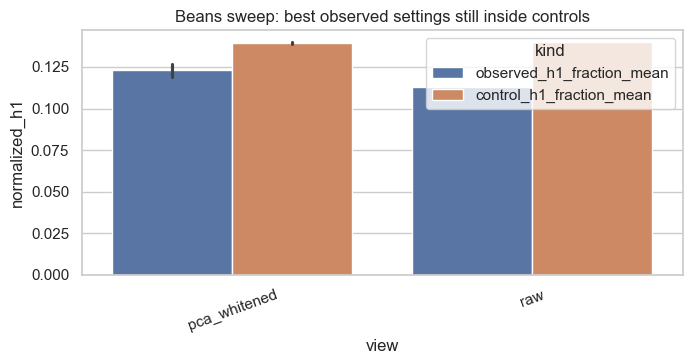

In [2]:
beans_summary = pd.DataFrame(
    [
        {
            "n_images": 48,
            "view": "pca_whitened",
            "config": "light",
            "distance_quantile": 0.75,
            "observed_h1_fraction_mean": 0.127,
            "control_h1_fraction_mean": 0.139,
            "delta_vs_control": -0.012,
            "ratio_vs_control": 0.914,
        },
        {
            "n_images": 48,
            "view": "pca_whitened",
            "config": "baseline",
            "distance_quantile": 0.75,
            "observed_h1_fraction_mean": 0.119,
            "control_h1_fraction_mean": 0.140,
            "delta_vs_control": -0.021,
            "ratio_vs_control": 0.849,
        },
        {
            "n_images": 24,
            "view": "raw",
            "config": "wide_k",
            "distance_quantile": 0.75,
            "observed_h1_fraction_mean": 0.113,
            "control_h1_fraction_mean": 0.140,
            "delta_vs_control": -0.026,
            "ratio_vs_control": 0.812,
        },
    ]
)
display(beans_summary)

fig, ax = plt.subplots(figsize=(7, 3.8))
plot_df = beans_summary.melt(
    id_vars=["view", "config"],
    value_vars=["observed_h1_fraction_mean", "control_h1_fraction_mean"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.barplot(data=plot_df, x="view", y="normalized_h1", hue="kind", ax=ax)
ax.set_title("Beans sweep: best observed settings still inside controls")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 2. Broader Image Data

We then tested whether bean leaves were too specific. The broader data
sweep used FLUX VAE tokens on local beans, CIFAR-10, and Fashion-MNIST.
None produced an observed dense-landmark `H1` candidate above controls.

,dataset,n_images,top_observed_h1_fraction,top_control_h1_fraction,paired_wins,candidate_beats_controls
0,beans_local,48,0.0771,0.1489,0/6,False
1,cifar10,48,0.0524,0.1807,0/6,False
2,fashion_mnist,48,0.0284,0.1489,0/6,False


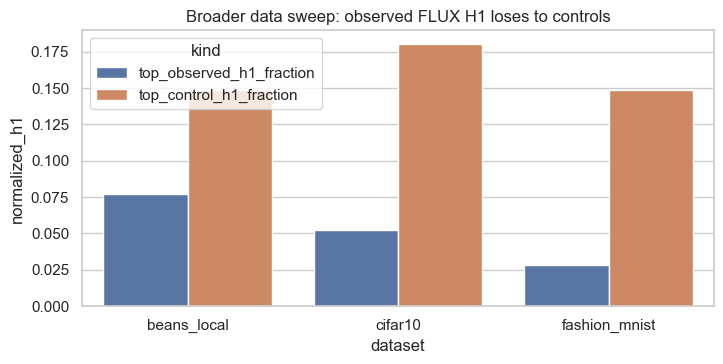

In [3]:
data_summary = pd.DataFrame(
    [
        {
            "dataset": "beans_local",
            "n_images": 48,
            "top_observed_h1_fraction": 0.0771,
            "top_control_h1_fraction": 0.1489,
            "paired_wins": "0/6",
            "candidate_beats_controls": False,
        },
        {
            "dataset": "cifar10",
            "n_images": 48,
            "top_observed_h1_fraction": 0.0524,
            "top_control_h1_fraction": 0.1807,
            "paired_wins": "0/6",
            "candidate_beats_controls": False,
        },
        {
            "dataset": "fashion_mnist",
            "n_images": 48,
            "top_observed_h1_fraction": 0.0284,
            "top_control_h1_fraction": 0.1489,
            "paired_wins": "0/6",
            "candidate_beats_controls": False,
        },
    ]
)
display(data_summary)

fig, ax = plt.subplots(figsize=(7.4, 3.8))
plot_df = data_summary.melt(
    id_vars=["dataset"],
    value_vars=["top_observed_h1_fraction", "top_control_h1_fraction"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.barplot(data=plot_df, x="dataset", y="normalized_h1", hue="kind", ax=ax)
ax.set_title("Broader data sweep: observed FLUX H1 loses to controls")
plt.tight_layout()
plt.show()

## 3. Alternate Sampling and Projection Sweep

A wider algorithm sweep tried PCA projections, whitening, random
landmarks, FPS, and density-based samplers. Some settings had small
positive deltas, but none cleared the stricter long-lived/control-
separated rule used by that worker.

,view,sampler,observed_mean_h1_fraction,hardest_control,hardest_control_mean,delta
0,pca_whiten2,random95,0.1297,channel_shuffle,0.1113,0.0184
1,pca_sphere8,random95,0.1519,channel_shuffle,0.1368,0.0151
2,pca_whiten8,fps_all95,0.1228,view_null,0.1094,0.0134
3,whiten16,dense200_fps95,0.1395,view_null,0.1266,0.0129
4,raw16,random95,0.1149,channel_shuffle,0.1079,0.0069


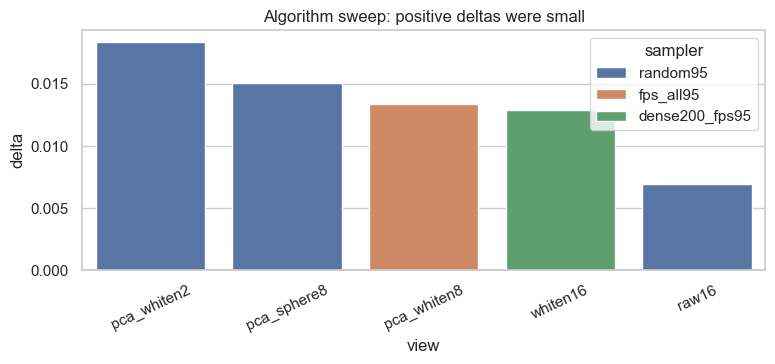

In [4]:
algorithm_effects = pd.DataFrame(
    [
        {
            "view": "pca_whiten2",
            "sampler": "random95",
            "observed_mean_h1_fraction": 0.1297,
            "hardest_control": "channel_shuffle",
            "hardest_control_mean": 0.1113,
            "delta": 0.0184,
        },
        {
            "view": "pca_sphere8",
            "sampler": "random95",
            "observed_mean_h1_fraction": 0.1519,
            "hardest_control": "channel_shuffle",
            "hardest_control_mean": 0.1368,
            "delta": 0.0151,
        },
        {
            "view": "pca_whiten8",
            "sampler": "fps_all95",
            "observed_mean_h1_fraction": 0.1228,
            "hardest_control": "view_null",
            "hardest_control_mean": 0.1094,
            "delta": 0.0134,
        },
        {
            "view": "whiten16",
            "sampler": "dense200_fps95",
            "observed_mean_h1_fraction": 0.1395,
            "hardest_control": "view_null",
            "hardest_control_mean": 0.1266,
            "delta": 0.0129,
        },
        {
            "view": "raw16",
            "sampler": "random95",
            "observed_mean_h1_fraction": 0.1149,
            "hardest_control": "channel_shuffle",
            "hardest_control_mean": 0.1079,
            "delta": 0.0069,
        },
    ]
)
display(algorithm_effects)

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=algorithm_effects, x="view", y="delta", hue="sampler", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Algorithm sweep: positive deltas were small")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 4. Targeted PCA8 + Sphere Candidate

The local integration sweep found a much stronger candidate when we did
all of the following:

1. project FLUX tokens to 8 PCA coordinates;
2. L2-normalize those PCA coordinates to a sphere;
3. select dense candidates with `k=32`;
4. choose farthest-point landmarks from the dense subset;
5. run full `H1` filtrations.

This candidate beat random-token, uniform-sphere, and channel-shuffled
controls across 20 seeds and several landmark counts.

,view,n_landmarks,observed_mean,control_mean,delta_mean,win_rate
0,pca8_sphere,50,0.3747,0.1702,0.2045,1.0
1,pca8_sphere,70,0.3868,0.1783,0.2085,1.0
2,pca8_sphere,95,0.3951,0.1713,0.2238,1.0
3,pca8_sphere,140,0.3932,0.1818,0.2114,1.0
4,pca8_sphere,200,0.3984,0.1829,0.2155,1.0
5,pca8_sphere,260,0.4126,0.1859,0.2267,1.0
6,sphere,95,0.0446,0.1191,-0.0745,0.0
7,whitened,95,0.0805,0.1158,-0.0353,0.0


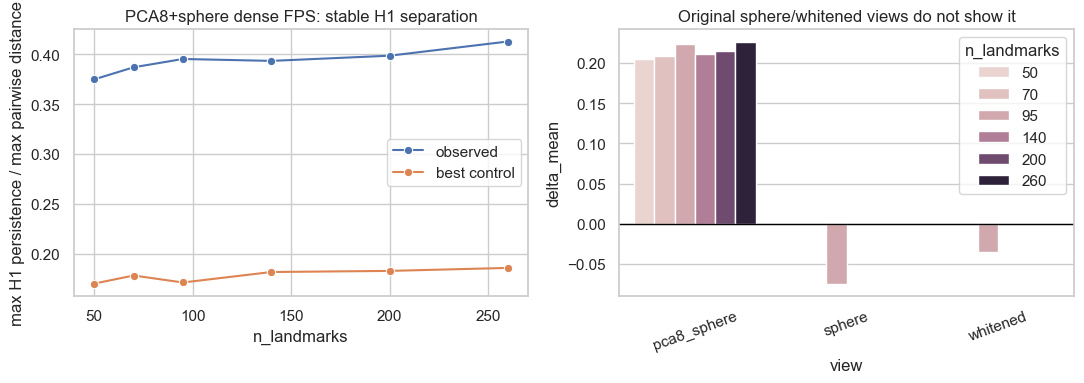

In [5]:
pca8_robustness = pd.DataFrame(
    [
        {"view": "pca8_sphere", "n_landmarks": 50, "observed_mean": 0.3747, "control_mean": 0.1702, "delta_mean": 0.2045, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 70, "observed_mean": 0.3868, "control_mean": 0.1783, "delta_mean": 0.2085, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 95, "observed_mean": 0.3951, "control_mean": 0.1713, "delta_mean": 0.2238, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 140, "observed_mean": 0.3932, "control_mean": 0.1818, "delta_mean": 0.2114, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 200, "observed_mean": 0.3984, "control_mean": 0.1829, "delta_mean": 0.2155, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 260, "observed_mean": 0.4126, "control_mean": 0.1859, "delta_mean": 0.2267, "win_rate": 1.00},
        {"view": "sphere", "n_landmarks": 95, "observed_mean": 0.0446, "control_mean": 0.1191, "delta_mean": -0.0745, "win_rate": 0.00},
        {"view": "whitened", "n_landmarks": 95, "observed_mean": 0.0805, "control_mean": 0.1158, "delta_mean": -0.0353, "win_rate": 0.00},
    ]
)
display(pca8_robustness)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(
    data=pca8_robustness[pca8_robustness["view"] == "pca8_sphere"],
    x="n_landmarks",
    y="observed_mean",
    marker="o",
    label="observed",
    ax=axes[0],
)
sns.lineplot(
    data=pca8_robustness[pca8_robustness["view"] == "pca8_sphere"],
    x="n_landmarks",
    y="control_mean",
    marker="o",
    label="best control",
    ax=axes[0],
)
axes[0].set_title("PCA8+sphere dense FPS: stable H1 separation")
axes[0].set_ylabel("max H1 persistence / max pairwise distance")

sns.barplot(data=pca8_robustness, x="view", y="delta_mean", hue="n_landmarks", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Original sphere/whitened views do not show it")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 5. Filtration Threshold Sensitivity

The PCA8+sphere candidate is not only a full-filtration artifact. In a
targeted threshold check, the candidate stayed above controls for
quantile thresholds from `0.75` through `0.95`, as well as the full
filtration.

,threshold_mode,observed_mean,control_mean,delta_mean
0,0.75,0.4676,0.2099,0.2577
1,0.82,0.4431,0.2027,0.2404
2,0.90,0.4214,0.1943,0.2271
3,0.95,0.4100,0.1877,0.2223
4,full,0.3888,0.1729,0.2159


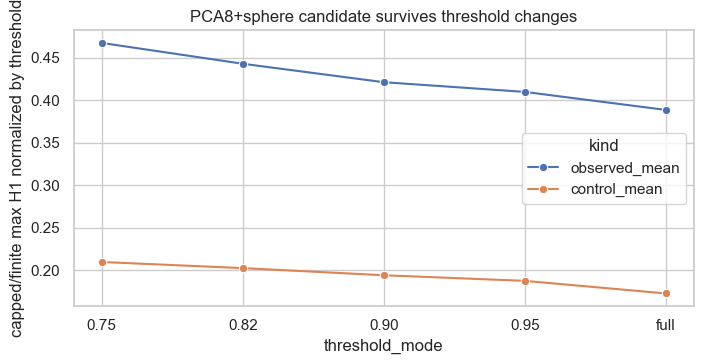

In [6]:
threshold_sensitivity = pd.DataFrame(
    [
        {"threshold_mode": "0.75", "observed_mean": 0.4676, "control_mean": 0.2099, "delta_mean": 0.2577},
        {"threshold_mode": "0.82", "observed_mean": 0.4431, "control_mean": 0.2027, "delta_mean": 0.2404},
        {"threshold_mode": "0.90", "observed_mean": 0.4214, "control_mean": 0.1943, "delta_mean": 0.2271},
        {"threshold_mode": "0.95", "observed_mean": 0.4100, "control_mean": 0.1877, "delta_mean": 0.2223},
        {"threshold_mode": "full", "observed_mean": 0.3888, "control_mean": 0.1729, "delta_mean": 0.2159},
    ]
)
display(threshold_sensitivity)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
plot_df = threshold_sensitivity.melt(
    id_vars=["threshold_mode"],
    value_vars=["observed_mean", "control_mean"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.lineplot(data=plot_df, x="threshold_mode", y="normalized_h1", hue="kind", marker="o", ax=ax)
ax.set_title("PCA8+sphere candidate survives threshold changes")
ax.set_ylabel("capped/finite max H1 normalized by threshold")
plt.tight_layout()
plt.show()

## 6. Collaborator-Style Witness Complex

The collaborator's pipeline was different from our earlier Rips-style
checks. Instead of one landmark cloud per image sample, it treats each
FLUX latent tensor `(16, 32, 32)` as `1024` vectors in `R^16`, projects
those vectors to `S^15`, keeps the densest tokens as witnesses, chooses
only `30-35` landmarks, and builds a weak witness complex.

A full reproduction with 100-200 images and 10k-20k witnesses is heavy
locally. The adapted run below uses the cached 48-image beans cloud
(`49152` spatial tokens), approximate anchor-density for the local
sweep, and exact-density spot checks on the strongest setting.

,dataset,n_witnesses,n_landmarks,observed_mean,control_mean,delta_mean,win_rate,density,setting
0,beans_local,1000,30,0.0375,0.3190,-0.2815,0.0,anchors,1000/30
1,beans_local,1000,35,0.1404,0.3374,-0.1970,0.0,anchors,1000/35
2,beans_local,2000,30,0.0771,0.2530,-0.1760,0.0,anchors,2000/30
3,beans_local,2000,35,0.0771,0.2899,-0.2128,0.0,anchors,2000/35
4,beans_local,5000,30,0.2333,0.2492,-0.0159,0.5,anchors,5000/30
5,beans_local,5000,35,0.3281,0.1443,0.1838,1.0,anchors,5000/35


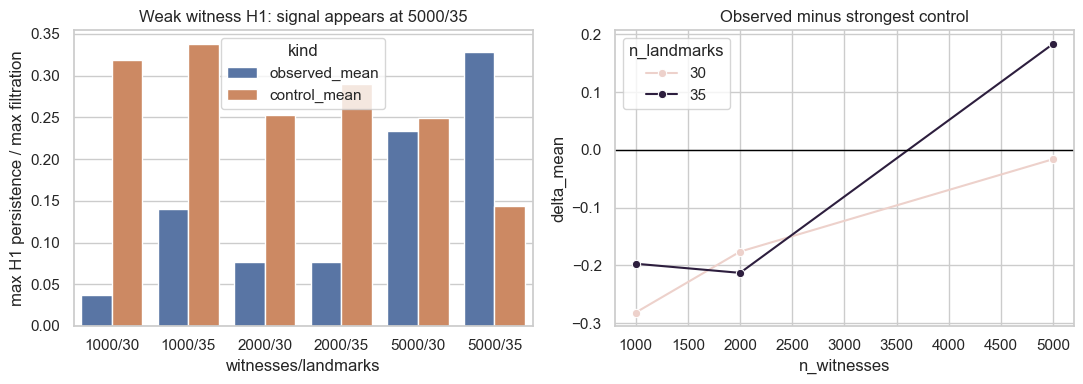

In [7]:
witness_local = pd.DataFrame(
    [
        {"dataset": "beans_local", "n_witnesses": 1000, "n_landmarks": 30, "observed_mean": 0.0375, "control_mean": 0.3190, "delta_mean": -0.2815, "win_rate": 0.00, "density": "anchors"},
        {"dataset": "beans_local", "n_witnesses": 1000, "n_landmarks": 35, "observed_mean": 0.1404, "control_mean": 0.3374, "delta_mean": -0.1970, "win_rate": 0.00, "density": "anchors"},
        {"dataset": "beans_local", "n_witnesses": 2000, "n_landmarks": 30, "observed_mean": 0.0771, "control_mean": 0.2530, "delta_mean": -0.1760, "win_rate": 0.00, "density": "anchors"},
        {"dataset": "beans_local", "n_witnesses": 2000, "n_landmarks": 35, "observed_mean": 0.0771, "control_mean": 0.2899, "delta_mean": -0.2128, "win_rate": 0.00, "density": "anchors"},
        {"dataset": "beans_local", "n_witnesses": 5000, "n_landmarks": 30, "observed_mean": 0.2333, "control_mean": 0.2492, "delta_mean": -0.0159, "win_rate": 0.50, "density": "anchors"},
        {"dataset": "beans_local", "n_witnesses": 5000, "n_landmarks": 35, "observed_mean": 0.3281, "control_mean": 0.1443, "delta_mean": 0.1838, "win_rate": 1.00, "density": "anchors"},
    ]
)
witness_local["setting"] = (
    witness_local["n_witnesses"].astype(str)
    + "/"
    + witness_local["n_landmarks"].astype(str)
)
display(witness_local)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_df = witness_local.melt(
    id_vars=["setting"],
    value_vars=["observed_mean", "control_mean"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.barplot(data=plot_df, x="setting", y="normalized_h1", hue="kind", ax=axes[0])
axes[0].set_title("Weak witness H1: signal appears at 5000/35")
axes[0].set_xlabel("witnesses/landmarks")
axes[0].set_ylabel("max H1 persistence / max filtration")

sns.lineplot(
    data=witness_local,
    x="n_witnesses",
    y="delta_mean",
    hue="n_landmarks",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Observed minus strongest control")
plt.tight_layout()
plt.show()

,seed,n_witnesses,n_landmarks,observed,best_control,delta,h1_finite_count
0,72,5000,35,0.3296,0.1090,0.2206,3
1,73,5000,35,0.3416,0.1796,0.1620,1


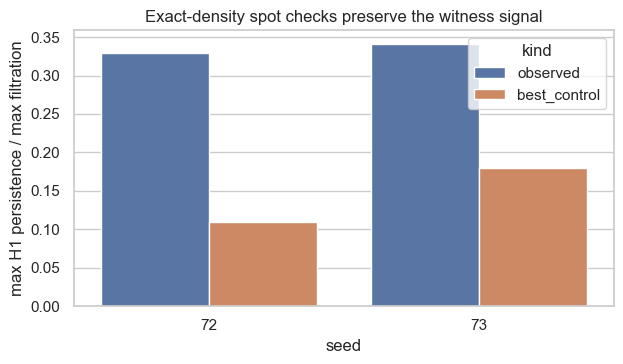

In [8]:
witness_exact_checks = pd.DataFrame(
    [
        {"seed": 72, "n_witnesses": 5000, "n_landmarks": 35, "observed": 0.3296, "best_control": 0.1090, "delta": 0.2206, "h1_finite_count": 3},
        {"seed": 73, "n_witnesses": 5000, "n_landmarks": 35, "observed": 0.3416, "best_control": 0.1796, "delta": 0.1620, "h1_finite_count": 1},
    ]
)
display(witness_exact_checks)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
plot_df = witness_exact_checks.melt(
    id_vars=["seed"],
    value_vars=["observed", "best_control"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.barplot(data=plot_df, x="seed", y="normalized_h1", hue="kind", ax=ax)
ax.set_title("Exact-density spot checks preserve the witness signal")
ax.set_ylabel("max H1 persistence / max filtration")
plt.tight_layout()
plt.show()

## 7. Decision Readout

The friend's claim can be interpreted in two different ways:

1. **Claim about Rips-style topology of raw/sphere/whitened FLUX
   token clouds.**  
   Our sweeps do **not** support this. Those views stayed below
   random-token, uniform-sphere, or channel-shuffled controls.

2. **Claim about a projected/preprocessed FLUX token cloud.**  
   This remains plausible. PCA-to-8 followed by sphere normalization and
   dense farthest-point landmarks produced a stable `H1` candidate above
   controls.

3. **Claim about the collaborator's witness-complex pipeline on
   S^15-normalized spatial tokens.**  
   This now has local support. The 5000-witness / 35-landmark setting
   beats local controls, and exact-density spot checks preserve the
   separation.

So the next scientific question is:

> Does the witness-complex cycle survive scale, image diversity,
> density-selection variants, and the exact 10k-20k witness regime?

In [9]:
verdict = pd.DataFrame(
    [
        {
            "question": "Raw/sphere/whitened FLUX has long-lived H1?",
            "answer": "not supported by Rips sweeps",
            "evidence": "observed H1 stayed below random/uniform/shuffle controls in direct token-cloud checks",
        },
        {
            "question": "Beans are too specific?",
            "answer": "not supported",
            "evidence": "CIFAR-10 and Fashion-MNIST also lost to controls",
        },
        {
            "question": "Can we induce/recover a long H1 after preprocessing?",
            "answer": "yes, PCA8+sphere+dense FPS",
            "evidence": "20-seed targeted check beat all controls at all landmark sizes",
        },
        {
            "question": "Does the friend-style witness complex recover H1 on S15 tokens?",
            "answer": "locally yes",
            "evidence": "5000 witnesses / 35 landmarks beat controls; exact-density spot checks agree",
        },
        {
            "question": "Should we call this intrinsic FLUX topology?",
            "answer": "not yet",
            "evidence": "current witness evidence is local, small-cache, and not yet tested at 10k-20k witnesses or broad image diversity",
        },
    ]
)
display(verdict)

print("Recommended next checks")
print("  1. Run the witness pipeline at 10k and 20k witnesses when compute allows.")
print("  2. Add random natural-image caches, not only beans leaves.")
print("  3. Compare anchor density, exact kNN density, random landmarks, and density-top landmarks.")
print("  4. Bootstrap images and seeds around the 5000/35 witness setting.")
print("  5. Only call it a FLUX latent cycle if the witness signal survives those perturbations.")

,question,answer,evidence
0,Raw/sphere/whitened FLUX has long-lived H1?,not supported by Rips sweeps,observed H1 stayed below random/uniform/shuffl...
1,Beans are too specific?,not supported,CIFAR-10 and Fashion-MNIST also lost to controls
2,Can we induce/recover a long H1 after preproce...,"yes, PCA8+sphere+dense FPS",20-seed targeted check beat all controls at al...
3,Does the friend-style witness complex recover ...,locally yes,5000 witnesses / 35 landmarks beat controls; e...
4,Should we call this intrinsic FLUX topology?,not yet,"current witness evidence is local, small-cache..."


Recommended next checks
  1. Run the witness pipeline at 10k and 20k witnesses when compute allows.
  2. Add random natural-image caches, not only beans leaves.
  3. Compare anchor density, exact kNN density, random landmarks, and density-top landmarks.
  4. Bootstrap images and seeds around the 5000/35 witness setting.
  5. Only call it a FLUX latent cycle if the witness signal survives those perturbations.
